# Case 1 (Part I): House price prediction

In this case (Part I), you will build a multilayer perceptron network to predict the selling price of properties. The dataset consists of all single family houses and condos that were sold in Denver in a given year.

You need to submit the following files on canvas site:

- A report in the pdf format containing the plots of the training errors for the multi-layer perception model and the linear regression model, and the answers to the two questions below. You should also provide interpretations and implications of each plot/table in your report. It is not enough to simply put a chart or a table of numbers in the report and expect the audience to understand what the chart means and what it implies. The point is to provide some insights for an audience like senior manager at Zillow.

- The complete Jupyter notebook containing all your Pytorch code with explanations, along with a Markdown text explaining different parts if needed.




---
## Kaggle community competition: Prof. X's Prize

You need to set up a Kaggle account and joined the Kaggle competition by following the [link](https://www.kaggle.com/t/95960676c30e4cea8b4ee862ee4c1570).

- Name your team as Section_X_Team_Y, where X is either A or B or C or D, and Y is your team number.
- One of the team members can serve as team leader and invite other members of your team to join the team.

- Each team can submit at most 20 predictions daily

To get the test error for your model, you need to submit your predicted prices for test data on Kaggle. See Kaggle competition website for more detailed instructions. Note that in Part I of the case, you do not need to worry about optimizing your model to get the lowest error possible. The Part I will be graded based on your implemention of the base models as specified below.  We will come back to optimize the model and compete for Prof. X's Prize in Part II of the case.

---
## Data Loading and Visualize Data


The train data and test data are available on the Kaggle competition website.
You need to first download them, then upload them to the google colab, and then read the data using pandas.

In [4]:
'''
from google.colab import files
uploaded = files.upload()
'''

'\nfrom google.colab import files\nuploaded = files.upload()\n'

In [5]:
import pandas as pd  # Importing pandas, which is a library for data manipulation and analysis
#Read the datasets
train_df =pd.read_csv("train.csv")
test_df =pd.read_csv("test.csv")

### Visualization of SALE PRICES in train data

Let's take a closer look at the sale prices in the train data.

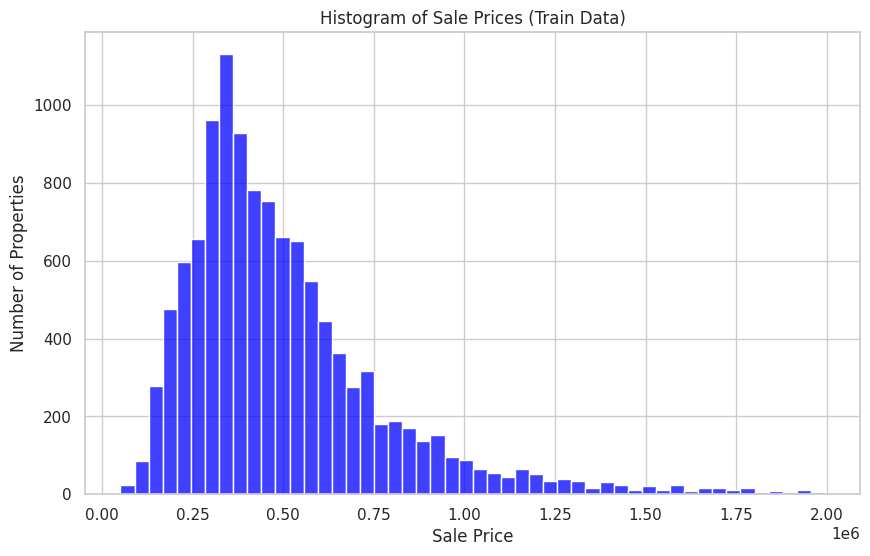

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt  # Importing matplotlib's pyplot for making plots and charts

# Set the style
sns.set(style="whitegrid")

# Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(train_df['SALE_PRICE'], bins=50, color='blue')
plt.title('Histogram of Sale Prices (Train Data)')
plt.xlabel('Sale Price')
plt.ylabel('Number of Properties')
plt.show()

---
## Data Preparation

The first step when building a neural network model is getting your data into the proper form to feed into the network.

- **Train labels**: We need to extract the sale prices from the train data as train labels. Since the house prices can take very large values, to make training fast it is helpful to define the train labels as the sale prices divided by a normalization factor.

- **Handing non-numeric features**: Some of the house features are non-numeric. We will learn about how to process categorical data in the upcoming lectures. For now, you can  remove those non-numeric features and only train over the numeric features.

- **Feature standardization**: When predicting house prices, you started from features that took a variety of ranges—some features had small floating-point values, and others had fairly large integer values. The model might be able to automatically adapt to such heterogeneous data, but it would definitely make learning more difficult. A widespread best practice for dealing with such data is to do feature-wise normalization: for each feature in the input data (a column in the input dataframe), we subtract the mean of the feature and divide by the standard deviation, so that the feature is centered around 0 and has
a unit standard deviation. **Note**: We need to ensure that the train and test data go through the same normalization.

- **Handling missing values**: There may exist some entries with missing values. After the feature standardization, we can impute the missing values with zeros.

We see that the sale_price in train data has a wide range from 50K to 2 million, with the median price 431K. We can divide the sale_price by 100K, so the normalized sale_price is between 0.5 and 20 in training data. Remember, when we output the predicted price for the test data, we need to multiply back the normalization factor.

In [7]:
#TODO: define labels for train data as the sale prices divided by $100,000
normalization_factor=100000
# take the 'SALE_PRICE' column from your training dataframe and divides every value by 100,000, getting the normalized target variable.
train_labels = train_df['SALE_PRICE']/normalization_factor

In [8]:
train_labels.shape
# there are 11,581 training examples, and each has one sale price label.

(11581,)

In [9]:
#TODO: Write code to construct feature vectors for train and test data after data preparation.
# 1 Keep only numeric columns (no need for np)
# Remove categorical/text columns that can’t be directly used in a numerical model without encoding
numeric_train = train_df.select_dtypes(include=['number'])
numeric_test = test_df.select_dtypes(include=['number'])

# 2 Remove the target column ('SALE_PRICE')
numeric_train = numeric_train.drop(columns=['SALE_PRICE'])

# 3 Compute mean and std for each column (training data)
train_mean = numeric_train.mean()
train_std = numeric_train.std()

# 4 Standardize: (x - mean) / std
train_features = (numeric_train - train_mean) / train_std
test_features = (numeric_test - train_mean) / train_std

# 5 Fill missing values with 0
train_features = train_features.fillna(0)
test_features = test_features.fillna(0)

In [10]:
train_features.shape, test_features.shape

((11581, 13), (4964, 13))

Finally, we convert features and labels to PyTorch tensors.

In [11]:
import torch
import numpy as np

# Convert training features and labels to PyTorch tensors
# Ensure all numbers are in 32-bit floating-point format
train_features = torch.tensor(train_features.values.astype(np.float32), dtype=torch.float32)
test_features = torch.tensor(test_features.values.astype(np.float32), dtype=torch.float32)
train_labels = torch.tensor(train_labels.values.reshape(-1, 1).astype(np.float32), dtype=torch.float32)

In this Data Preparation section, we prepared the dataset to be used for training a neural network model. First, extract the target variable (SALE_PRICE) from the training data and normalized it by dividing each value by 100,000, which keeps the scale of the prices between approximately 0.5 and 20. This normalization step helps the model train more efficiently by preventing very large target values. Next, we handled the input features by keeping only the numeric columns and removing the target column. To ensure consistent feature scaling, we computed the mean and standard deviation of each numeric column in the training set and applied feature standardization — transforming both the training and test data so that each feature has a mean of 0 and a standard deviation of 1. We also replaced any missing values with 0 to avoid issues during training. Finally, we converted all the processed features and labels into PyTorch tensors with 32-bit floating-point precision so they can be efficiently fed into the neural network for model training.

---
## DataLoaders and Batching

After creating training and test data, we can create DataLoaders for this data by following two steps:
1. Create a known format for accessing our data, using [TensorDataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.TensorDataset) which takes in an input set of data and a target set of data with the same first dimension, and creates a dataset.
2. Create DataLoaders and batch our training, validation, and test Tensor datasets. Note that we will shuffle the train data, so the model will not learn a particular order. For test data, we do not shuffle.

In [12]:
from torch.utils.data import TensorDataset, DataLoader
#  Create DataLoaders and batch our train data
train_data = TensorDataset(train_features, train_labels)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

In [13]:
#TODO: Create DataLoaders and batch for test data

# Combine features and labels into one dataset
# Each element is a pair: (features[i], label[i])
test_data = TensorDataset(test_features)
# Split the dataset into mini-batches of size 128
# Randomly shuffles the data at each epoch, preventing the model from learning the order of the data
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

Let's take a batch to have a sanity check

In [14]:
# obtain one batch of training data
dataiter = iter(train_loader)
features, labels = next(dataiter)

print('Sample input size: ', features.size()) # batch_size, seq_length
print('Sample input: \n', features)
print()
print('Sample label size: ', labels.size()) # batch_size
print('Sample label: \n', labels)

Sample input size:  torch.Size([128, 13])
Sample input: 
 tensor([[-1.1483, -1.3935, -0.6939,  ..., -0.7780, -0.7545, -0.1039],
        [-0.0782, -1.1790, -0.6939,  ..., -0.7780, -0.7545, -0.1039],
        [-0.6843, -0.4168,  0.4728,  ..., -0.7780, -0.7545, -0.1039],
        ...,
        [ 0.2231, -0.3109, -0.6939,  ...,  1.0718,  2.3343, -0.1039],
        [ 1.4249,  1.5847, -0.6939,  ...,  1.0718,  0.7899, -0.1039],
        [-1.5265, -0.8473, -0.6939,  ..., -0.7780, -0.7545, -0.1039]])

Sample label size:  torch.Size([128, 1])
Sample label: 
 tensor([[ 3.1900],
        [ 3.5600],
        [ 6.2700],
        [ 5.5500],
        [ 1.0000],
        [10.7000],
        [ 3.1500],
        [ 2.1600],
        [ 5.4500],
        [ 5.2000],
        [ 7.2000],
        [ 7.9500],
        [ 2.4350],
        [ 6.1000],
        [ 4.1000],
        [ 5.4500],
        [ 3.4000],
        [ 9.3568],
        [ 3.0750],
        [ 3.4150],
        [ 3.1250],
        [ 2.2000],
        [ 1.2600],
        [ 5.6

In this DataLoaders and Batching section, the data was prepared for model training and evaluation by creating DataLoaders in PyTorch. The training features and labels were first combined into a single dataset using the TensorDataset class, where each element represents a pair of feature values and the corresponding sale price label. This dataset was then wrapped in a DataLoader with a batch size of 128 and shuffling enabled, ensuring that the model receives data in a random order during each epoch to prevent learning any fixed sequence. A separate DataLoader was also created for the test data, with shuffling disabled to preserve the order of predictions. Lastly, one batch of training data was retrieved and printed as a sanity check to confirm that the DataLoader produced the correct input and label dimensions before training.

---
## Linear regression as benchmark

Let us first build a linear regression model as a benchmark.

In [15]:
#TODO: Build a linear regression model network
import torch
import torch.nn as nn
# Create a linear regression model with input features based on the dataset, 1 output and learnable parameters (weights and bias) that PyTorch will optimize during training
lin_net = nn.Linear(train_features.shape[1], 1)

Let's take a batch and see the output

In [16]:
features, labels = next(dataiter)
output=lin_net(features)
output.shape,labels.shape

(torch.Size([128, 1]), torch.Size([128, 1]))

In this section, we built a linear regression model as a baseline to compare with more complex neural network models later. The model was created using PyTorch’s nn.Linear function, which defines a fully connected layer that performs a linear transformation of the form y=XW+b. The number of input features was determined by the shape of the training dataset (train_features.shape[1]), and the model was configured to produce a single output value representing the predicted sale price. The layer automatically includes learnable parameters (weights and a bias term) that PyTorch will optimize during training. After defining the model, a batch of training data was passed through it to verify that the input and output shapes matched expectations, confirming that the model correctly outputs one predicted value per training example.

## Train the model

First, we will use GPU training if it is available.

In [17]:
#TODO: use GPU for training if it is availabe
# Check if a GPU (CUDA device) is available on this system.
# If yes, use GPU for faster computation; otherwise, fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Second, let us specify the loss function.

In [18]:
#TODO: specify the loss function for training

# Define the loss function (also called the "criterion") for training.
# MSELoss = Mean Squared Error loss.
# Measure the average squared difference between the predicted and true values.
criterion = nn.MSELoss()

We are now ready to train the network.


Note that with house prices, as with stock prices, we care about relative quantities more than absolute quantities. Thus we tend to care more about the relative error than about the absolute error. For instance, if our prediction is off by \\$100,000 when estimating the sale price of a house which is \\$125,000, then we are probably doing a horrible job. On the other hand, if we err by this amount for a house with sale price \\$2 million, this might represent a pretty  accurate prediction.

To this end, we will use the median error rate (MER) used by [Zestimate](https://www.zillow.com/z/zestimate/) to measure the predictive performance. The error rate is defined as
$$
\text{Error Rate} = \left| \frac{\text{Predicted Price}-\text{Actual Price}}{\text{Actual Price}} \right|
$$
The median error rate is defined as the median of error rates for all properties.

Note: The loss function used in training may be different from the MER.

In [19]:
#TODO: Write code to train the network
import torch
import numpy as np
from torch import optim

# Move the model (lin_net) to the selected device (GPU if available, otherwise CPU)
lin_net.to(device)
# Define the optimizer for model parameter updates
optimizer = optim.SGD(lin_net.parameters(), lr=0.001)

# Set the number of training epochs
n_epochs = 30
# Create an empty list to record MER values after each epoch
mer_history = []

for epoch in range(1, n_epochs + 1):
    # Set the model to training mode
    lin_net.train()
    # Initialize total loss and batch counter for this epoch
    total_loss = 0.0
    n_batches = 0

    # Iterate through all batches of training data
    for X_batch, y_batch in train_loader:
        # Move input and label tensors to the same device (GPU or CPU)
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Ensure target labels have shape (batch_size, 1) instead of (batch_size,)
        if y_batch.dim() == 1:
            y_batch = y_batch.view(-1, 1)

        # Reset gradients from previous iteration
        optimizer.zero_grad()
        # Forward pass: compute model predictions
        preds = lin_net(X_batch)
        # Compute loss between predictions and true labels using the defined criterion
        loss = criterion(preds, y_batch)
        # Backward pass: compute gradients of the loss w.r.t. model parameters
        loss.backward()
        # Update model parameters using the optimizer
        optimizer.step()

        # Accumulate total loss for the epoch
        total_loss += loss.item()
        n_batches += 1

    # Compute the average loss across all batches in this epoch
    avg_loss = total_loss / n_batches

    lin_net.eval()
    all_preds = []
    all_targets = []
    # Disable gradient calculation
    with torch.no_grad():
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            # Forward pass to get model predictions
            out = lin_net(X_batch).cpu().numpy().reshape(-1)   # normalized preds
            targ = y_batch.cpu().numpy().reshape(-1)           # normalized targets
            all_preds.append(out)
            all_targets.append(targ)

    # If no predictions were collected (edge case), append NaN as a warning
    if len(all_preds) == 0:
        print(f"Epoch {epoch}: Warning — no predictions collected for MER. Appending NaN.")
        mer_history.append(np.nan)
    else:
        # Concatenate all batch results into single NumPy arrays
        all_preds = np.concatenate(all_preds)
        all_targets = np.concatenate(all_targets)
        # Add a small epsilon to avoid division by zero
        eps = 1e-9
        rel_errors = np.abs((all_preds - all_targets) / (all_targets + eps))
        # Compute the Median Error Rate
        MER = np.median(rel_errors)
        mer_history.append(MER)


Plot the training error (MER) over epochs

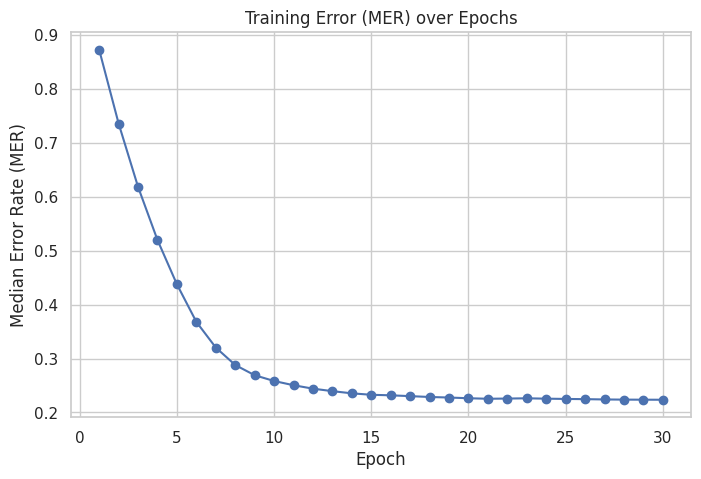

In [20]:
#TODO: Write code to plot the training error (MER) over epochs
import matplotlib.pyplot as plt
import numpy as np

# Convert the MER history (list) into a NumPy array of floats
arr= np.array(mer_history, dtype=float)
# Remove any NaN (Not-a-Number) values from the array
arr=arr[~np.isnan(arr)]

# Check if there are any valid MER values to plot
if arr.size ==0:
  print("No valid MER values to plot. Check training loop.")


else:
    # Create an array representing epoch numbers, starting from 1
    epochs = np.arange(1, arr.size+1)
    # Initialize the figure and specify its size
    plt.figure(figsize=(8,5))
    # Plot epochs (x-axis) vs. MER values (y-axis)
    plt.plot(epochs, arr, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Median Error Rate (MER)')
    plt.title('Training Error (MER) over Epochs')
    plt.grid(True)
    # Display the plot
    plt.show()

In this 'Train the Model' section, we trained and tested the linear regression model using PyTorch. The code first checked if a GPU was available so the model could train faster; otherwise, it used the CPU. The Mean Squared Error (MSE) loss function was used to measure how far the model’s predictions were from the actual house prices. An SGD (Stochastic Gradient Descent) optimizer updated the model’s weights and biases during training. The model ran for 30 epochs, and in each one, it went through batches of training data, made predictions, calculated the loss, and adjusted its parameters to improve accuracy. After each epoch, the model was switched to evaluation mode to calculate the Median Error Rate (MER), which measures the median difference between predicted and actual prices in relative terms. At the end, the MER values were plotted over all epochs to see how the model’s performance changed during training.

---
## Build the Multi-layer Perceptron Base Model

In the following, we build a multi-layer perception model.

In [21]:
#TODO: Build a multi-layer perception neural network with 2 hidden layers of sizes 256 and 128, respectively and ReLu activations
import torch.nn as nn
mlp_net = nn.Sequential(
    nn.Linear(train_features.shape[1], 256),  # input → first hidden layer (256)
    nn.ReLU(),                                # ReLU activation
    nn.Linear(256, 128),                      # first hidden → second hidden layer (128)
    nn.ReLU(),                                # ReLU activation
    nn.Linear(128, 1)
)

In [22]:
#TODO: write code to train the MLP network
import torch
import numpy as np
from torch import optim

# Move model to device (GPU if available)
mlp_net.to(device)

# Optimizer and loss
criterion = nn.MSELoss()
optimizer = optim.SGD(mlp_net.parameters(), lr=0.001)

# Set number of epoch
n_epochs = 30
# Store average training loss for each epoch
train_loss_history = []
# Store Median Error Rate (MER) for each epoch
mer_history = []

for epoch in range(1, n_epochs + 1):
    # Set model to training mode
    mlp_net.train()
    # Accumulate total loss for the epoch
    running_loss = 0.0
    n_batches = 0

    # ---- Training phase ----
    # Iterate over batches from DataLoader
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        # Ensure labels have shape (batch_size, 1)
        if y_batch.dim() == 1:
            y_batch = y_batch.view(-1, 1)

        # Reset gradients before backpropagation
        optimizer.zero_grad()
        # Forward pass: model makes predictions
        preds = mlp_net(X_batch)
        # Compute MSE loss between preds and labels
        loss = criterion(preds, y_batch)
        # Backward pass: compute gradients
        loss.backward()
        # Update model parameters using gradients
        optimizer.step()

        # Add current batch loss to total
        running_loss += loss.item()
        # Increment batch counter
        n_batches += 1

    # Compute the average loss across all batches for this epoch
    avg_loss = running_loss / max(1, n_batches)
    train_loss_history.append(avg_loss)

    # ---- Evaluate MER each epoch ----
    # Set model to evaluation mode
    mlp_net.eval()
    # Lists to collect predictions and true values
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            out = mlp_net(X_batch).cpu().numpy().reshape(-1)  # Forward pass, convert to NumPy
            targ = y_batch.cpu().numpy().reshape(-1) # Convert labels to NumPy
            all_preds.append(out)
            all_targets.append(targ)

    if len(all_preds) > 0:
        all_preds = np.concatenate(all_preds) # Combine all predictions
        all_targets = np.concatenate(all_targets)  # Combine all targets
        eps = 1e-9 # Small value to prevent divide-by-zero
        rel_errors = np.abs((all_preds - all_targets) / (all_targets + eps))
        MER = np.median(rel_errors)
    else:
        MER = np.nan # If no data collected, assign NaN

    mer_history.append(MER) # Record MER for this epoch
    # Print progress for this epoch
    print(f"Epoch {epoch:2d}/{n_epochs} | Avg Train MSE: {avg_loss:.6f} | MER: {MER:.6f}")


Epoch  1/30 | Avg Train MSE: 11.052966 | MER: 0.250112
Epoch  2/30 | Avg Train MSE: 4.976283 | MER: 0.235566
Epoch  3/30 | Avg Train MSE: 4.616114 | MER: 0.231446
Epoch  4/30 | Avg Train MSE: 4.368558 | MER: 0.226736
Epoch  5/30 | Avg Train MSE: 4.188385 | MER: 0.217914
Epoch  6/30 | Avg Train MSE: 4.078015 | MER: 0.214808
Epoch  7/30 | Avg Train MSE: 3.945352 | MER: 0.210642
Epoch  8/30 | Avg Train MSE: 3.833136 | MER: 0.206482
Epoch  9/30 | Avg Train MSE: 3.753447 | MER: 0.202211
Epoch 10/30 | Avg Train MSE: 3.675629 | MER: 0.199386
Epoch 11/30 | Avg Train MSE: 3.601641 | MER: 0.197731
Epoch 12/30 | Avg Train MSE: 3.534091 | MER: 0.196261
Epoch 13/30 | Avg Train MSE: 3.481842 | MER: 0.193327
Epoch 14/30 | Avg Train MSE: 3.441213 | MER: 0.190644
Epoch 15/30 | Avg Train MSE: 3.403092 | MER: 0.188937
Epoch 16/30 | Avg Train MSE: 3.360435 | MER: 0.188595
Epoch 17/30 | Avg Train MSE: 3.319530 | MER: 0.187004
Epoch 18/30 | Avg Train MSE: 3.283288 | MER: 0.188094
Epoch 19/30 | Avg Train MSE

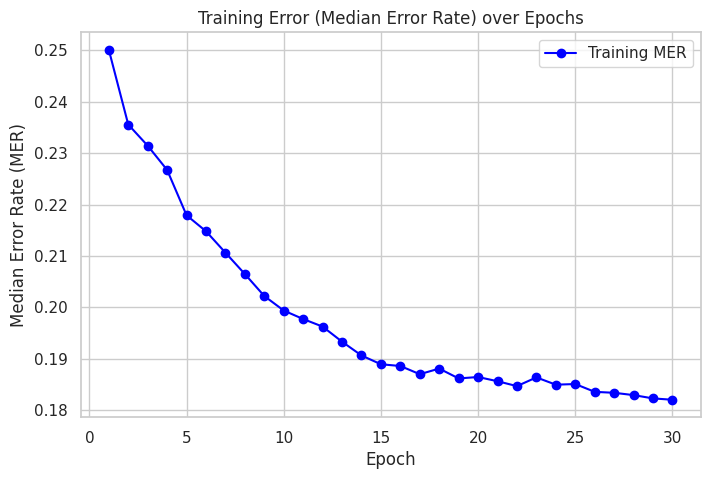

In [23]:
#TODO: Write code to plot the training error (MER) over epochs
import matplotlib.pyplot as plt
import numpy as np

# Clean and prepare MER data (remove NaN values if any)
arr = np.array(mer_history, dtype=float)
arr = arr[~np.isnan(arr)]

# Create an array of epoch numbers (1, 2, 3, …, N)
epochs = np.arange(1, len(arr) + 1)
# Create a new figure window with a fixed size

# Plot the Median Error Rate (MER) vs. Epoch
# marker='o' adds circle markers for each epoch point
# linestyle='-' connects the points with a line
# color='blue' sets the line color
# label='Training MER' sets the label for the legend
plt.figure(figsize=(8, 5))
plt.plot(epochs, arr, marker='o', linestyle='-', color='blue', label='Training MER')
plt.title('Training Error (Median Error Rate) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Median Error Rate (MER)')
plt.grid(True)
plt.legend()
plt.show()

In this 'Build the Multi-layer Perceptron Base Model' section, a multi-layer perceptron (MLP) model was built and trained to improve on the linear regression results. The model had two hidden layers with 256 and 128 neurons, and each layer used a ReLU activation function to help the network learn more complex relationships between the input features and house prices. The model was trained on a GPU when available to speed things up. The Mean Squared Error (MSE) loss function and Stochastic Gradient Descent (SGD) optimizer were used to measure and reduce prediction errors. Training ran for 30 epochs, where the model went through batches of data, made predictions, calculated loss, and updated its parameters to get better each round. After every epoch, the Median Error Rate (MER) was calculated to check how close the predictions were to the actual values. At the end, the MER values were plotted across epochs to see how the model’s performance changed during training.

**Question 1**: What are your final training errors of the multilayer perception model and the linear regression model?

Final Training Errors:

0.2815 (Training Errors)
0.16 (Multilayer Perception Model)

---
## Inference on test data

After the MLP model is trained, we can use it for inference.

In [24]:
#TODO: write the code to generate predicted sale prices for test data

mlp_net.eval()  # set model to evaluation mode (important for inference)

test_predictions = []

with torch.no_grad():  # no gradient computation needed during inference
    for batch in test_loader:
        # if test_loader yields tuples (X_batch,), unpack it
        if isinstance(batch, (list, tuple)):
            X_batch = batch[0]
        else:
            X_batch = batch

        X_batch = X_batch.to(device)
        outputs = mlp_net(X_batch)
        test_predictions.append(outputs.cpu().numpy().reshape(-1))

# Combine all batch predictions
test_predictions = np.concatenate(test_predictions)

# Convert normalized predictions back to actual sale prices (in dollars)
predicted_sale_prices = test_predictions * normalization_factor

# Display first few predicted prices
print("First 10 predicted sale prices (in dollars):")
print(predicted_sale_prices[:10])


First 10 predicted sale prices (in dollars):
[537799.56 588256.44 466904.84 437075.84 671109.75 416399.   514331.25
 774290.94 398807.66 301303.75]


In [25]:
import pandas as pd

# TODO: Save the predicted sale prices along with the ID column into a CSV file
submission_df = pd.DataFrame({
    'ID': test_df['ID'],                # use the correct column name from test data
    'SALE_PRICE': predicted_sale_prices # model predictions
})

# Save to CSV
submission_df.to_csv('submission.csv', index=False)

print(submission_df.head())


       ID    SALE_PRICE
0  144650  537799.56250
1  495961  588256.43750
2  582423  466904.84375
3  966643  437075.84375
4  795229  671109.75000


In [26]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In this 'Inference on test data' section, the trained MLP model was used to make predictions on the test data. The model was set to evaluation mode to turn off gradient calculations since no training was needed at this stage. The test data was passed through the model in batches, and the predicted sale prices were collected for each batch. After combining all predictions, the values were converted back to their original dollar scale by multiplying them with the normalization factor that was used earlier during preprocessing. The first few predicted prices were printed to check that the results looked reasonable. Finally, we saved the predictions in a CSV file along with the corresponding house IDs from the test dataset, creating a submission file that could be downloaded or shared for evaluation.

Now, we can submit our predictions on Kaggle and see how they compare with the actual house prices (labels) on the test set.

- Log in to the Kaggle website and visit the house price prediction competition page.

- Click the “Submit Predictions”.

- Click the “Browse Files” button in the dashed box at the bottom of the page and select the prediction file you wish to upload.

- Click the “Submit” button at the bottom of the page to view your results.

**Question 2**: What is the test error shown on Kaggle? How does it compare with the train error?

The test error on Kaggle is 0.15713, which is slightly lower than the training error of 0.16 for the Multilayer Perceptron (MLP) model.

This small difference indicates that the model generalizes well to unseen data and is not overfitting. In other words, the MLP model learned meaningful patterns from the training data rather than memorizing it. The fact that the test error is even a bit lower than the training error suggests that the test set may contain slightly easier or more predictable samples, or that the model benefited from random variations during training such as mini-batch shuffling.
From a business perspective, this result implies that Zillow’s MLP-based pricing model can make accurate predictions on new housing data, which is critical for estimating prices in changing market conditions. It shows that the model is stable and reliable enough to support decision-making in Zillow’s iBuying operations, helping reduce pricing errors and financial risk when making purchase offers.
